In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, RobustScaler, StandardScaler, FunctionTransformer

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.cluster import KMeans
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity


import warnings
warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
device

device(type='cpu')

In [3]:
original_df=pd.read_csv("data_extraction_test.csv")

In [4]:
df=original_df.drop("jobma_catcher_id", axis=1)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4466 entries, 0 to 4465
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   company_size             4466 non-null   object 
 1   is_premium               4466 non-null   int64  
 2   subscription_status      4466 non-null   int64  
 3   jobma_catcher_status     4466 non-null   int64  
 4   sub_users                4466 non-null   int64  
 5   wallet_amount            4466 non-null   float64
 6   is_unlimited             4466 non-null   int64  
 7   plan_type                4466 non-null   int64  
 8   subscription_sum         4466 non-null   float64
 9   subscription_count       4466 non-null   int64  
 10  invitations              4466 non-null   int64  
 11  pre_recorded_kit_counts  4466 non-null   int64  
 12  number_of_jobs_posted    4466 non-null   int64  
 13  pre_rec_interview_taken  4466 non-null   int64  
 14  days_since_login        

In [6]:
binary_columns = ['is_premium',
                  'subscription_status',
                  'jobma_catcher_status',
                  'is_unlimited',
                  'plan_type',
                 ]
                   
numerical_columns= ['sub_users',
                    'wallet_amount',
                    'subscription_count',
                    'invitations',
                    'pre_recorded_kit_counts',
                    'number_of_jobs_posted',
                    'pre_rec_interview_taken',
                   'days_since_login']

categorical_columns = ['company_size']
ordinal_columns =['subscription_sum']

In [7]:
# Clean binary values , # Remove negatives and  clamp to 0
def log_transform(X):
    X = X.copy()
    X[X <= 0] = 1e-10
    return np.log(X)

def clean_binary(X):
    return X.apply(lambda col: col.map(lambda val: 1 if pd.to_numeric(val, errors='coerce') > 0 else 0).astype(int))

def clean_categorical(X):
    return X.apply(lambda col: col.map(lambda val: str(val).strip().lower() if pd.notnull(val) else 'others'))

def clean_numerical(X):
    return X.apply(lambda col: pd.to_numeric(col, errors='coerce'))

def clean_ordinal(X):
    return X.apply(lambda col: pd.to_numeric(col, errors='coerce')).clip(lower=0)
    

In [8]:
# Binary pipeline
binary_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_binary, validate=False)),
                                  ('imputer', SimpleImputer(strategy='most_frequent')),
                                 ])

categorical_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_categorical, validate=False)),
                                       ('imputer', SimpleImputer(strategy='most_frequent')),
                                       ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
                                      ])

ordinal_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_ordinal, validate=False)),
                                   ('imputer', SimpleImputer(strategy='median')),
                                   ('log_transform', FunctionTransformer(lambda x: np.log1p(x), validate=False)),
                                  ])

numerical_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_numerical, validate=False)),
                                     ('imputer', SimpleImputer(strategy='mean')),
                                    ])

preprocessor = ColumnTransformer(transformers=[('bin', binary_pipeline, binary_columns),
                                               ('cat', categorical_pipeline, categorical_columns), 
                                               ('ord', ordinal_pipeline, ordinal_columns),
                                               ('num', numerical_pipeline, numerical_columns),
                                              ])

# Final pipeline
pipeline = Pipeline([('preprocessing', preprocessor),
                    ('scaler', StandardScaler())])

In [9]:
preprocessor

ColumnTransformer(transformers=[('bin',
                                 Pipeline(steps=[('cleaner',
                                                  FunctionTransformer(func=<function clean_binary at 0x0000021D294100D0>)),
                                                 ('imputer',
                                                  SimpleImputer(strategy='most_frequent'))]),
                                 ['is_premium', 'subscription_status',
                                  'jobma_catcher_status', 'is_unlimited',
                                  'plan_type']),
                                ('cat',
                                 Pipeline(steps=[('cleaner',
                                                  FunctionTransformer(func=<function clea...
                                                  FunctionTransformer(func=<function <lambda> at 0x0000021D29410670>))]),
                                 ['subscription_sum']),
                                ('num',
                                 Pipeline(steps=[('cleaner',
                                                  FunctionTransformer(func=<function clean_numerical at 0x0000021D294101F0>)),
                                                 ('imputer', SimpleImputer())]),
                                 ['sub_users', 'wallet_amount',
                                  'subscription_count', 'invitations',
                                  'pre_recorded_kit_counts',
                                  'number_of_jobs_posted',
                                  'pre_rec_interview_taken',
                                  'days_since_login'])])

In [10]:
X = df.copy()

In [11]:
X_scaled = pipeline.fit_transform(X)

In [12]:
class CustomDataset(Dataset):
    def __init__(self, data):
        self.data = torch.tensor(data, dtype=torch.float32)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

In [13]:
batch_size = 16
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
dataset = CustomDataset(X_tensor)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [14]:
len(X_scaled), len(X_tensor), len(dataset), len(dataloader), batch_size, X_scaled.shape

(4466, 4466, 4466, 280, 16, (4466, 19))

In [15]:
# Autoencoder for robustness
class AutoEncoder(nn.Module):
    def __init__(self, input_shape):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_shape, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32)
        )

        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_shape)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded

In [16]:
X_scaled.shape[1], X_tensor.shape[1]

(19, 19)

In [17]:
input_dim = X_tensor.shape[1]
model = AutoEncoder(input_dim)
model.to(device)

AutoEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=19, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=19, bias=True)
  )
)

In [18]:
input_dim

19

# Optimizer and scheduler and other loss function

In [19]:
# Loss functions
mse_loss_function = nn.SmoothL1Loss()
cosine_loss_function = nn.CosineEmbeddingLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5)

# Training Model

In [20]:
torch.manual_seed(42)
epochs = 10
model.train()

for epoch in range(epochs):
    epoch_total_loss = 0
    for batch_X in dataloader:
        batch_X = batch_X.to(device)
        encoded, decoded = model(batch_X)
        mse_loss = mse_loss_function(decoded, batch_X)

        # Cosine Embedding Loss
        batch_size = encoded.size(0)
        target_labels = torch.ones(batch_size, device=device)

        # Shuffling the encoded vectors 
        permuted_indices = torch.randperm(batch_size, device=device)
        encoded_shuffled = encoded[permuted_indices]

        # Calculating Cosine Embedding Loss
        cosine_loss = cosine_loss_function(encoded, encoded_shuffled, target_labels)
        total_loss = mse_loss + cosine_loss

        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()
        epoch_total_loss += total_loss.item()
    training_loss = epoch_total_loss / len(dataloader)
    print(f'Epoch {epoch+1}/{epochs} | Training Loss: {training_loss:.5f}')
    scheduler.step(training_loss)

Epoch 1/10 | Training Loss: 0.24769
Epoch 2/10 | Training Loss: 0.17264
Epoch 3/10 | Training Loss: 0.09376
Epoch 4/10 | Training Loss: 0.06282
Epoch 5/10 | Training Loss: 0.05582
Epoch 6/10 | Training Loss: 0.04262
Epoch 7/10 | Training Loss: 0.03792
Epoch 8/10 | Training Loss: 0.03162
Epoch 9/10 | Training Loss: 0.02866
Epoch 10/10 | Training Loss: 0.02669


In [21]:
model.eval()
with torch.no_grad():
    encoder, _ = model(X_tensor)
latent_np = encoder.cpu().numpy()

In [22]:
wcss = []
silhouette_scores = []
k_range = range(2,11)
torch.manual_seed(42)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(latent_np)
    wcss.append(kmeans.inertia_)  # Inertia = WCSS
    silhouette_scores.append(silhouette_score(latent_np, labels))

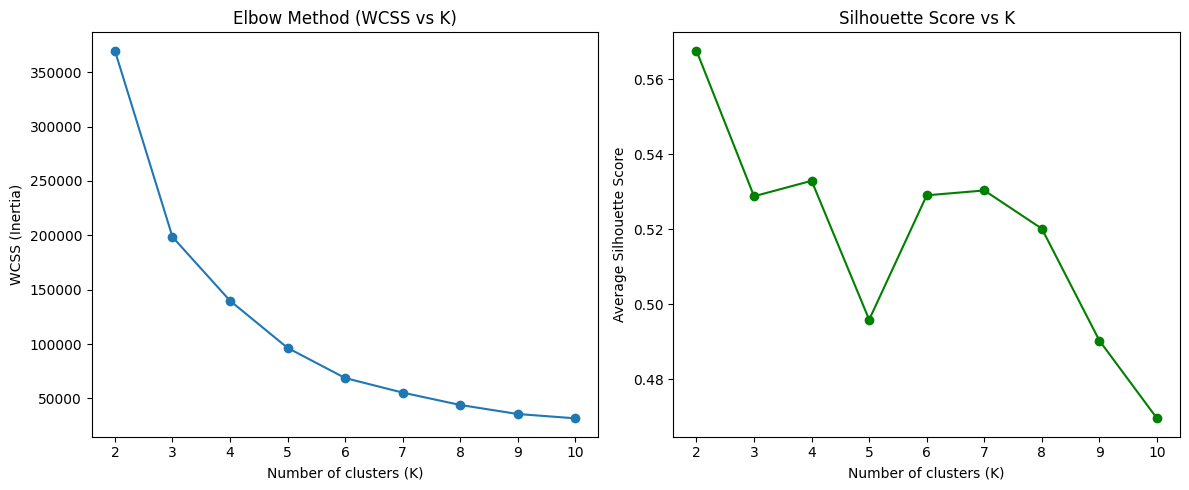

In [23]:
#Elbow Rule to decide the number of clusters with silhoute score
torch.manual_seed(42)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, wcss, marker='o')
plt.title('Elbow Method (WCSS vs K)')
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS (Inertia)')

# Step 5: Plot Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='o', color='green')
plt.title('Silhouette Score vs K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Average Silhouette Score')

plt.tight_layout()
plt.show()

In [24]:
#Initialising KMeans
kmeans = KMeans(n_clusters=3, n_init=input_dim)
cluster_ids = kmeans.fit_predict(latent_np)
cluster_centers = torch.tensor(kmeans.cluster_centers_, dtype=torch.float32).to(device)

In [25]:
# Deep Embedding Clusturing Model
class DEC(nn.Module):
    def __init__(self, encoder, cluster_centers):
        super(DEC, self).__init__()
        self.encoder = encoder
        self.cluster_centers = nn.Parameter(cluster_centers)

    def forward(self, x):
        z = self.encoder(x)
        q = 1.0 / (1.0 + torch.sum((z.unsqueeze(1) - self.cluster_centers)**2, dim=2))
        q = q.pow((1 + 1) / 2.0)
        q = (q.t() / torch.sum(q, dim=1)).t()
        return q, z

def target_distribution(q):
    weight = q**2 / q.sum(0)
    return (weight.t() / weight.sum(1)).t()  

In [26]:
dec = DEC(model.encoder, cluster_centers.clone()).to(device)

In [27]:
kl_loss = nn.KLDivLoss(reduction='batchmean')
optimizer = torch.optim.Adam(dec.parameters(), lr=1e-4)

In [28]:
torch.manual_seed(42)
dec.train()
num_epochs = 20
for epoch in range(num_epochs):
    for batch in dataloader:
        x = batch.to(device)
        q, z = dec(x)
        p = target_distribution(q)

        # Compute loss
        loss = kl_loss(q.log(), p)
        
        # Backpropogation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {loss.item():.4f}")

Epoch 1/20, Loss: 0.0644
Epoch 2/20, Loss: 0.0000
Epoch 3/20, Loss: 0.0431
Epoch 4/20, Loss: 0.0585
Epoch 5/20, Loss: 0.0007
Epoch 6/20, Loss: 0.0364
Epoch 7/20, Loss: 0.0410
Epoch 8/20, Loss: 0.0705
Epoch 9/20, Loss: 0.0478
Epoch 10/20, Loss: 0.0175
Epoch 11/20, Loss: 0.0421
Epoch 12/20, Loss: 0.0532
Epoch 13/20, Loss: 0.0189
Epoch 14/20, Loss: 0.0215
Epoch 15/20, Loss: 0.0000
Epoch 16/20, Loss: 0.0737
Epoch 17/20, Loss: 0.0000
Epoch 18/20, Loss: 0.0721
Epoch 19/20, Loss: 0.0417
Epoch 20/20, Loss: 0.0131


In [29]:
# 2d plotting

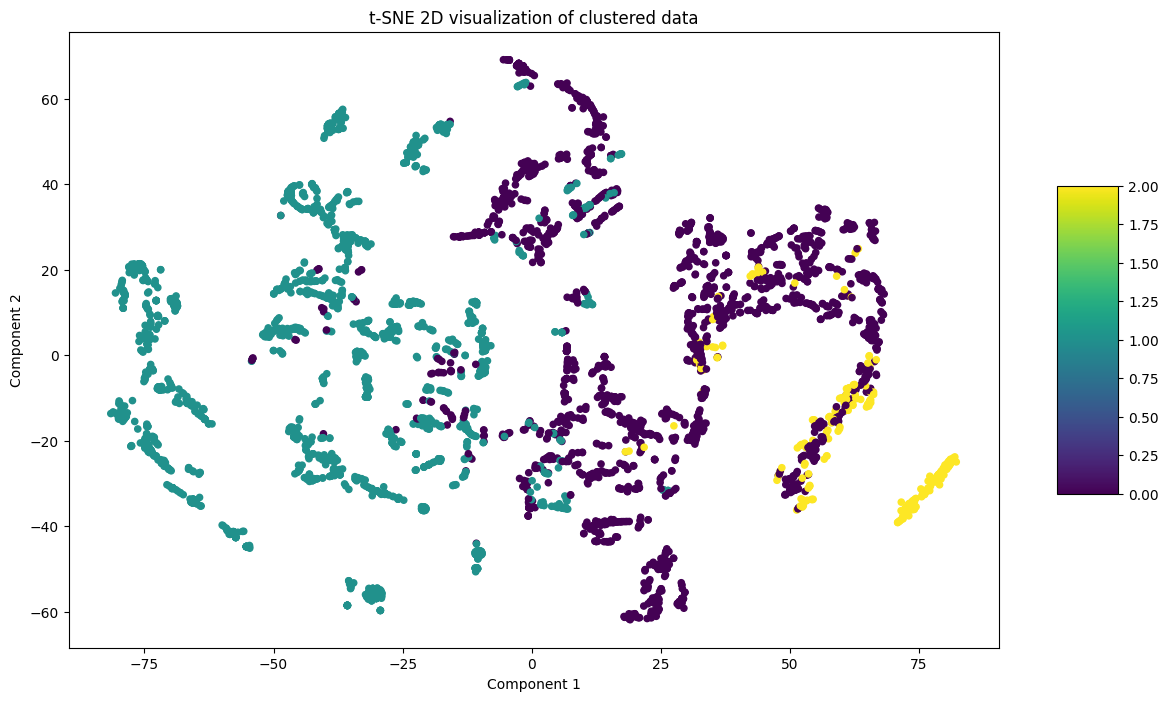

In [30]:
with torch.no_grad():
    _, z = dec(X_tensor.to(device))
    z_2d = TSNE(n_components=2, random_state=42).fit_transform(z.cpu().numpy())
fig, ax = plt.subplots(figsize=(15, 8))
scatter = ax.scatter(z_2d[:, 0], z_2d[:, 1], c=cluster_ids, cmap='viridis', s=20)
ax.set_title('t-SNE 2D visualization of clustered data')
ax.set_xlabel('Component 1')
ax.set_ylabel('Component 2')
plt.colorbar(scatter, ax=ax, shrink=0.5, aspect=5)
plt.show()

# 3d representation

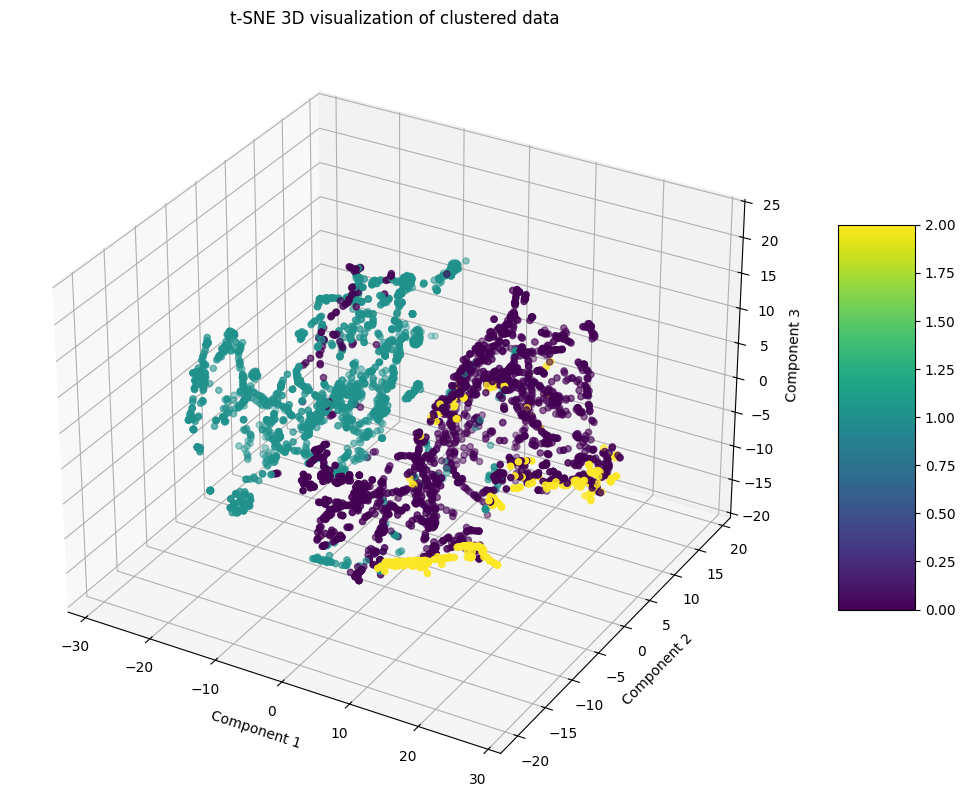

In [31]:
from mpl_toolkits.mplot3d import Axes3D

dec.eval()
with torch.no_grad():
    _, z = dec(X_tensor.to(device))
    z_3d = TSNE(n_components=3, random_state=42).fit_transform(z.cpu().numpy())

    fig = plt.figure(figsize=(15, 10))
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(z_3d[:, 0], z_3d[:, 1], z_3d[:, 2], c=cluster_ids, cmap='viridis', s=20)
    
    ax.set_title('t-SNE 3D visualization of clustered data')
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
    ax.set_zlabel('Component 3')
    plt.colorbar(scatter, ax=ax, shrink=0.5, aspect=5)
    plt.show()

In [35]:
import numpy as np
from collections import Counter

cluster_ids_np = np.array(cluster_ids)
cluster_counts = Counter(cluster_ids_np)
for i, (cluster_id, count) in enumerate(sorted(cluster_counts.items())):
    print(f"Cluster {i + 1} : {count} points")

Cluster 1 : 2250 points
Cluster 2 : 1973 points
Cluster 3 : 243 points


In [33]:
sample_data = pd.DataFrame({'company_size': ['1-25'],
                            'is_premium': [1],
                            'subscription_status': [2],
                            'jobma_catcher_status': [1],
                            'sub_users': [2],
                            'wallet_amount': [60],
                            'is_unlimited': [1],
                            'plan_type': [0],
                            'subscription_sum': [0.6],
                            'subscription_count': [5],
                            'invitations': [10],
                            'number_of_jobs_posted': [2],
                            'pre_recorded_kit_counts': [1],
                            'pre_rec_interview_taken': [10],
                            'days_since_login': [1111],
                           })

sample_scaled = pipeline.transform(sample_data)
sample_tensor = torch.tensor(sample_scaled, dtype=torch.float32).to(device)
model.eval()
with torch.no_grad():
    sample_embedding, _ = model(sample_tensor)
cos_sim = cosine_similarity(sample_embedding.cpu().numpy(), encoder.cpu().numpy())
top_k_idx = np.argsort(cos_sim[0])[::-1][:5]


In [34]:
recommended_clients = df.iloc[top_k_idx]
recommended_clients

,company_size,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_sum,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,days_since_login
4121,1-25,0,1,1,0,150.0,0,0,0.0,2,0,0,0,0,552
4261,1-25,0,2,1,0,170.0,0,0,0.0,2,0,0,0,0,428
4014,1-25,0,2,1,0,55.0,0,0,0.0,2,0,0,0,0,618
2132,1-25,0,1,1,0,110.0,0,0,0.6,2,0,1,0,0,342
4018,1-25,0,2,1,0,60.0,0,0,0.0,3,0,0,0,0,616


In [40]:
sample_cluster = kmeans.predict(sample_embedding.cpu().numpy())[0]
print("Top 5 similar client indices:", top_k_idx)
print(f"The sample client belongs to Cluster {sample_cluster + 1}")

Top 5 similar client indices: [4121 4261 4014 2132 4018]
The sample client belongs to Cluster 2
